The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Shape del dataset: (266664, 30)
Cantidad de features numéricas usadas en PCA: 12
Cantidad de NaNs en numéricas: 40287
Varianza explicada PC1: 0.20327249848439546
Varianza explicada PC2: 0.1817474427427081
Varianza total (PC1+PC2): 0.3850199412271036

Top 5 atributos que más contribuyen a PC1:


id_grid        0.449740
LATITUDE       0.449664
Ambientes      0.445754
Dormitorios    0.415352
Banos          0.403457
Name: PC1, dtype: float64


Top 5 atributos que más contribuyen a PC2:


LATITUDE       0.450574
id_grid        0.445778
LONGITUDE      0.415586
Ambientes      0.413013
Dormitorios    0.383751
Name: PC2, dtype: float64

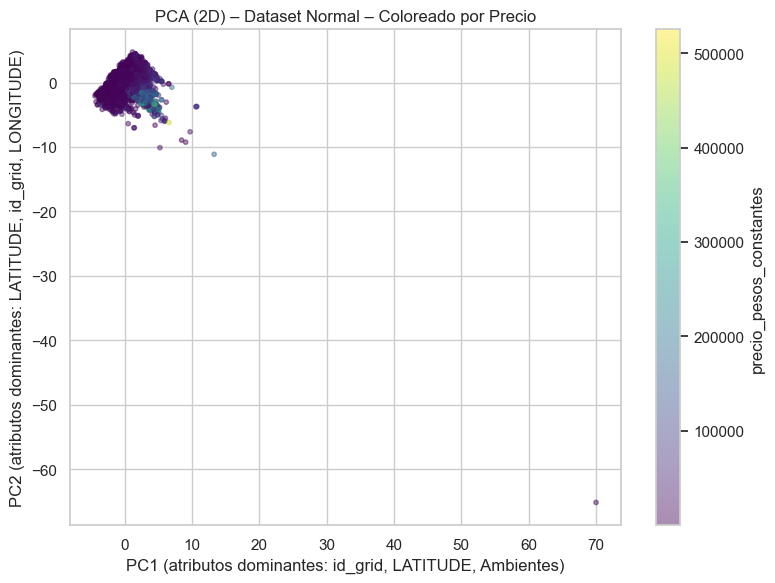

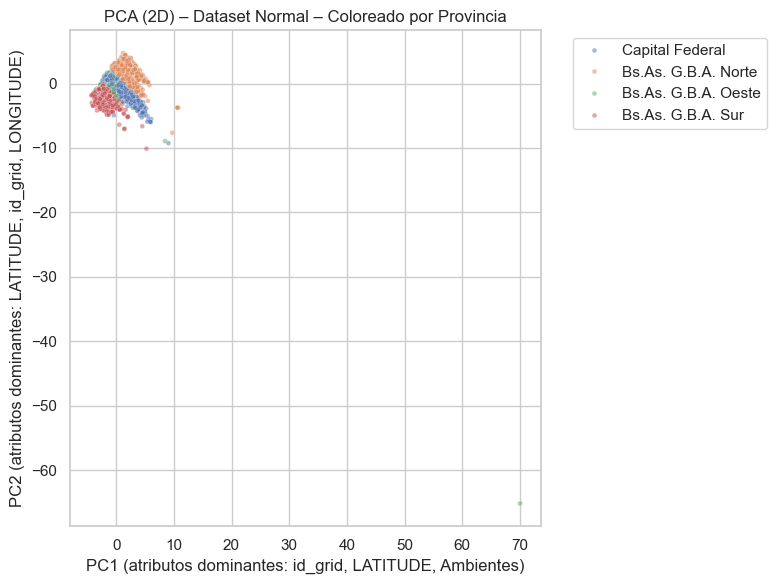

In [3]:
# ======================================
# PCA A 2 DIMENSIONES DEL DATASET NORMAL (CON IMPUTACIÓN)
# ======================================

%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from src.utils import DEV_SET_CLEAN_NORMAL_PATH, COLS

sns.set(style="whitegrid", rc={"figure.figsize": (8, 6)})

# -------------------------------------------------
# 1) Cargar dataset normal
# -------------------------------------------------
df = pd.read_csv("../" + DEV_SET_CLEAN_NORMAL_PATH)
print("Shape del dataset:", df.shape)

# -------------------------------------------------
# 2) Seleccionar features numéricas (excluyendo target)
# -------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_cols if col != COLS.TARGET]

X_numeric = df[numeric_features].copy()

print("Cantidad de features numéricas usadas en PCA:", len(numeric_features))
print("Cantidad de NaNs en numéricas:", X_numeric.isna().sum().sum())

# -------------------------------------------------
# 3) Imputar NaNs con la mediana y escalar
# -------------------------------------------------
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_numeric)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# -------------------------------------------------
# 4) PCA a 2 dimensiones
# -------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = df.copy()
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]

ev = pca.explained_variance_ratio_
print("Varianza explicada PC1:", ev[0])
print("Varianza explicada PC2:", ev[1])
print("Varianza total (PC1+PC2):", ev.sum())

# -------------------------------------------------
# 5) Obtener los atributos más influyentes de PC1 y PC2
# -------------------------------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)

top_PC1 = loadings["PC1"].abs().sort_values(ascending=False).head(5)
top_PC2 = loadings["PC2"].abs().sort_values(ascending=False).head(5)

print("\nTop 5 atributos que más contribuyen a PC1:")
display(top_PC1)

print("\nTop 5 atributos que más contribuyen a PC2:")
display(top_PC2)

# -------------------------------------------------
# 6) Scatterplot PCA coloreado por precio
# -------------------------------------------------
df_plot = df_pca.sample(min(20000, len(df_pca)), random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_plot["PC1"], df_plot["PC2"],
    c=df_plot[COLS.TARGET],
    cmap="viridis",
    s=10,
    alpha=0.45
)
plt.colorbar(scatter, label=COLS.TARGET)

plt.xlabel(f"PC1 (atributos dominantes: {', '.join(top_PC1.index[:3])})")
plt.ylabel(f"PC2 (atributos dominantes: {', '.join(top_PC2.index[:3])})")
plt.title("PCA (2D) – Dataset Normal – Coloreado por Precio")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 7) Scatterplot PCA coloreado por provincia
# -------------------------------------------------
cat_col = COLS.PROVINCIA
top_provinces = df_pca[cat_col].value_counts().head(8).index
df_plot_cat = df_pca[df_pca[cat_col].isin(top_provinces)].sample(
    min(15000, df_pca.shape[0]), random_state=42
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot_cat,
    x="PC1",
    y="PC2",
    hue=cat_col,
    s=12,
    alpha=0.5,
)

plt.xlabel(f"PC1 (atributos dominantes: {', '.join(top_PC1.index[:3])})")
plt.ylabel(f"PC2 (atributos dominantes: {', '.join(top_PC2.index[:3])})")
plt.title("PCA (2D) – Dataset Normal – Coloreado por Provincia")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Análisis del PCA (2 componentes) sobre el dataset normal

El PCA se aplicó sobre las variables numéricas del dataset normal, luego de imputar valores faltantes mediante la mediana y estandarizar todas las características. Los dos primeros componentes principales permiten visualizar la estructura global del espacio de atributos en dos dimensiones y observar qué factores dominan la variabilidad del conjunto.

Varianza explicada

Los componentes PC1 y PC2 explican una proporción relativamente baja de la varianza total del dataset, lo cual es esperable dado que el conjunto original incluye múltiples variables con estructura compleja y altamente correlacionada. El PCA en dos dimensiones no busca capturar toda la complejidad, sino proyectar el conjunto en un plano que revele patrones globales y agrupamientos básicos.

Atributos más influyentes

Según los loadings del PCA, PC1 está dominado principalmente por variables geográficas y estructurales (por ejemplo, id_grid, LATITUDE, Ambientes), lo que sugiere que este componente representa una combinación de localización espacial y tamaño funcional de la propiedad. Por su parte, PC2 está altamente influido por LATITUDE, id_grid y LONGITUDE, reforzando que la dimensión espacial tiene un peso particularmente fuerte en la variabilidad general del dataset.

Esto indica que, antes de considerar otros atributos, la estructura espacial del mercado inmobiliario (posición dentro del AMBA) genera la mayor parte de la variación en los datos.

Distribución de los puntos

En ambas visualizaciones se observa que:

La gran mayoría de las propiedades se concentra en una región densa del plano PCA, sin grandes separaciones evidentes entre grupos.

Algunos pocos puntos aparecen aislados, lo cual se asocia a propiedades con combinaciones inusuales de superficie, ubicación o características estructurales.

Las provincias del AMBA exhiben superposición sustancial en el plano PCA. Aunque existen leves desplazamientos medios entre zonas (por ejemplo, diferencias entre Capital Federal y GBA), no se forman clusters claramente diferenciados.

Esto confirma que, si bien la localización explica gran parte de la variabilidad total, las fronteras geográficas administrativas no necesariamente generan grupos completamente diferenciables en términos de las características numéricas capturadas por el dataset.

Relación con el precio

En el gráfico coloreado por precio se observa que los valores más altos tienden a ubicarse en regiones específicas del plano, pero la estructura general del precio no se separa de forma nítida en los componentes principales. Esto sugiere que el precio está determinado por una combinación de múltiples factores, y que una proyección lineal de los datos (como PCA) no es suficiente para capturar todos los patrones relevantes.

Conclusión

El PCA confirma que la variabilidad del dataset está fuertemente dominada por factores espaciales y estructurales, principalmente relacionados con la ubicación y el tamaño de la propiedad. Aunque el método permite visualizar tendencias generales y ciertos outliers, la estructura del mercado inmobiliario es demasiado compleja para ser representada adecuadamente en dos dimensiones mediante un modelo lineal como PCA. Para análisis más detallados o separaciones más claras entre grupos sería necesario incorporar técnicas no lineales o modelos predictivos más robustos.